In [1]:
import sys
import tensorflow as tf

print("Python:", sys.executable)
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

I0000 00:00:1787968009.167479    1702 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787968009.925056    1702 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787968013.673810    1702 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Python: /home/yuvika_agrawal/tf_gpu_env/bin/python
TensorFlow: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import sys
import os
import tensorflow as tf
import pandas as pd
from tensorflow.keras import layers, models 
from tensorflow.keras.applications import EfficientNetB0
print("GPU Available:", tf.config.list_physical_devices('GPU'))


sys.path.append("src/")
from preprocessing import (
     build_paths_labels, make_dataset,
     compute_class_weights,build_oversampled_paths_labels
)

root_dir = "archive"

# Dataset directories
train_images_dir = os.path.join(root_dir, "train_images", "train_images")
valid_images_dir = os.path.join(root_dir, "val_images", "val_images")
test_images_dir  = os.path.join(root_dir, "test_images", "test_images")

train_df = pd.read_csv(os.path.join(root_dir, "train_clean.csv"))
valid_df = pd.read_csv(os.path.join(root_dir, "valid.csv"))
test_df  = pd.read_csv(os.path.join(root_dir, "test.csv"))


# `tf.data` pipeline

train_paths, train_labels = build_paths_labels(train_df, train_images_dir)
valid_paths, valid_labels = build_paths_labels(valid_df, valid_images_dir)
test_paths, test_labels   = build_paths_labels(test_df, test_images_dir)

train_ds = make_dataset(train_paths, train_labels, training=True, batch_size=16)
valid_ds = make_dataset(valid_paths, valid_labels, training=False, batch_size=16)
test_ds  = make_dataset(test_paths, test_labels, training=False, batch_size=16)

class_weight_dict = compute_class_weights(train_labels)
print("Class weights:", class_weight_dict)


GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


I0000 00:00:1787968021.871361    1702 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1763 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Class weights: {0: 0.403072625698324, 1: 1.9835051546391753, 2: 0.7362244897959184, 3: 3.7973684210526315, 4: 2.5427312775330395}


In [3]:
print("Train samples:", len(train_paths))
print("Valid samples:", len(valid_paths))
print("Test samples :", len(test_paths))

images, labels = next(iter(train_ds))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image dtype:", images.dtype)

Train samples: 2886
Valid samples: 366
Test samples : 366


I0000 00:00:1787968035.237429    2180 shuffle_dataset_op.cc:453] ShuffleDatasetV3:3: Filling up shuffle buffer (this may take a while): 137 of 2886
I0000 00:00:1787968055.601171    2180 shuffle_dataset_op.cc:453] ShuffleDatasetV3:3: Filling up shuffle buffer (this may take a while): 526 of 2886
I0000 00:00:1787968074.931973    2180 shuffle_dataset_op.cc:453] ShuffleDatasetV3:3: Filling up shuffle buffer (this may take a while): 897 of 2886
I0000 00:00:1787968084.962997    2180 shuffle_dataset_op.cc:453] ShuffleDatasetV3:3: Filling up shuffle buffer (this may take a while): 1098 of 2886
I0000 00:00:1787968095.236496    2180 shuffle_dataset_op.cc:453] ShuffleDatasetV3:3: Filling up shuffle buffer (this may take a while): 1269 of 2886
I0000 00:00:1787968105.288465    2180 shuffle_dataset_op.cc:453] ShuffleDatasetV3:3: Filling up shuffle buffer (this may take a while): 1472 of 2886
I0000 00:00:1787968125.022221    2180 shuffle_dataset_op.cc:453] ShuffleDatasetV3:3: Filling up shuffle buffe

Image batch shape: (16, 224, 224, 3)
Label batch shape: (16,)
Image dtype: <dtype: 'float32'>


In [4]:
#Enable Mixed Precision Training
#every layers needs to be float 16 except the final layer .

from tensorflow.keras import mixed_precision

mixed_precision.set_global_policy('mixed_float16')
print("Compute dtype:", mixed_precision.global_policy().compute_dtype)
print("Variable dtype:", mixed_precision.global_policy().variable_dtype)

Compute dtype: float16
Variable dtype: float32


Model Building with frozen backbone

In [5]:
def build_model(input_shape=(224,224,3),num_classes=5, dropout_rate=0.3):
    base_model = EfficientNetB0(include_top=False, weights='imagenet', input_shape=input_shape)
    base_model.trainable = False  # Freeze the base model

    inputs= layers.Input(shape=input_shape)
    x=base_model(inputs, training=False) #specify is against training=False to avoid updating batchnorm statistics
    x=layers.GlobalAveragePooling2D()(x)
    x=layers.Dropout(dropout_rate)(x)
    outputs=layers.Dense(num_classes, activation='softmax', dtype='float32')(x)

    model = models.Model(inputs=inputs, outputs=outputs)
    return model,base_model

model,base_model= build_model()
model.summary()

E0000 00:00:1787968183.639330    1702 util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,055,976 (15.47 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [6]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#Large LR as only the head is being trained. 

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath="outputs/models/phase1_head_best.keras",
        monitor='val_loss',
        save_best_only=True
    )]


history_phase1 = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=20,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

class weights are applied to the training loss and not validation loss , 14th epoch uploaded as the best head model with validation accuracy : 75 percent

In [ ]:
model.load_weights("outputs/models/phase1_head_best.keras")

base_model.trainable = True  # Unfreeze the base model for fine-tuning

fine_tune_at= len(base_model.layers)-30 

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False
for layer in base_model.layers[fine_tune_at:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False  # Keep BatchNormalization layers frozen
    else:
        layer.trainable = True

# Recompile — required any time .trainable status is changed 
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # much lower LR — small, careful updates
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_phase2 = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(
        filepath='outputs/models/phase2_finetuned_best.keras',
        monitor='val_loss', save_best_only=True
    )
]

history_phase2 = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=20,
    class_weight=class_weight_dict,
    callbacks=callbacks_phase2
)

Initial fine-tuning run had a bug: BatchNorm layers' trainable flag was unconditionally overwritten to True after being set to False, so BN's affine parameters (gamma/beta) were not actually frozen as intended — though running statistics were unaffected since the model's training=False call on the backbone kept them fixed regardless. Restarted fine-tuning cleanly from the Phase 1 checkpoint with the corrected freeze logic.

also for more epochs and LR Schedular added for smooth convergence and better performance as their for no early stopping previously by the model.

In [ ]:
# clean restart from head-only baseline
model.load_weights("outputs/models/phase1_head_best.keras")  

base_model.trainable = True
fine_tune_at = len(base_model.layers) - 30

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False
for layer in base_model.layers[fine_tune_at:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False
    else:
        layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_phase2 = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(
        filepath='outputs/models/phase2_finetuned_best.keras',
        monitor='val_loss', save_best_only=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7)
]

history_phase2 = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=40,
    class_weight=class_weight_dict,
    callbacks=callbacks_phase2
)

EPOCH 3 - val_accuracy≈0.76, val_loss≈0.61 (best model) , after 3rd epoch no 6 consecutive epochs without improvement (val_loss).

In [7]:
model.load_weights("outputs/models/phase2_finetuned_best.keras")

test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

/home/yuvika_agrawal/tf_gpu_env/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 4 variables whereas the saved optimizer has 34 variables. 
  saveable.load_own_variables(store)
/home/yuvika_agrawal/tf_gpu_env/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 0 variables. 
  saveable.load_own_variables(store)
I0000 00:00:1787968217.965239    2115 service.cc:153] XLA service 0x7e18840638b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1787968217.965515    2115 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6 (Driver: 13.3.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1787968220.483050    2115 dump_mlir_util.cc:269] disabling MLIR cra

23/23 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.7923 - loss: 0.5509 
Test Loss: 0.5509, Test Accuracy: 0.7923


Accuracy treats every correct/incorrect prediction as equally weighted, which hides exactly the failure mode that matters most in the project: missing a severe case. Therefore:

1.Quadratic Weighted Kappa(QWK): (predicted - actual)² , Confusing grade 3 with grade 4 is a minor, forgivable error but Confusing grade 0 with grade 4 is a severe, dangerous error , more is the wrong prediction , more is the penalization. 

2.Per-class recall: recall exposes that are the rarer classes are not miss by the model . (recall on grade 3 and grade 4)

3.Confusion matrix: shows what mistakes were actually done 

4.Precision : works on detecting flase alarms , out of all the severe detected cases which are actually the true ones.

              precision    recall  f1-score   support

     Grade 0       0.97      0.97      0.97       199
     Grade 1       0.43      0.67      0.52        30
     Grade 2       0.71      0.67      0.69        87
     Grade 3       0.33      0.41      0.37        17
     Grade 4       0.73      0.33      0.46        33

    accuracy                           0.79       366
   macro avg       0.63      0.61      0.60       366
weighted avg       0.81      0.79      0.79       366

Quadratic Weighted Kappa: 0.8262
Figure saved to: outputs/figures/06_confusion_matrix_baseline.png


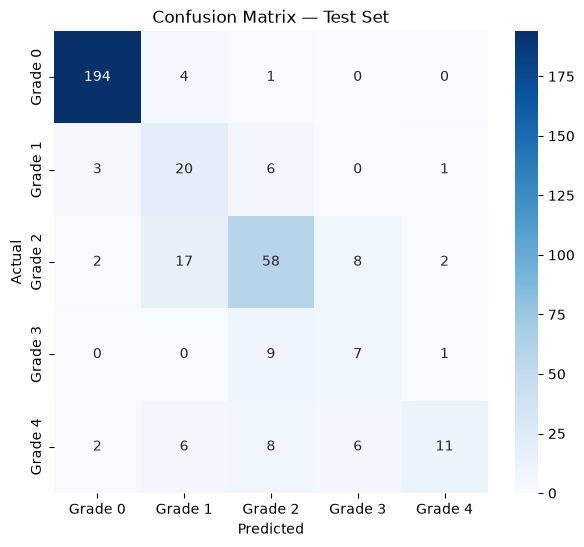

In [8]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score
import seaborn as sns
import matplotlib.pyplot as plt
import sys
sys.path.append("src/")
from data_utils import save_figure


y_true, y_pred = [], []
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

y_true, y_pred = np.array(y_true), np.array(y_pred)

print(classification_report(y_true, y_pred, target_names=[f"Grade {i}" for i in range(5)]))

qwk = cohen_kappa_score(y_true, y_pred, weights='quadratic')
print(f"Quadratic Weighted Kappa: {qwk:.4f}")

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f"Grade {i}" for i in range(5)],
            yticklabels=[f"Grade {i}" for i in range(5)], ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — Test Set")
save_figure(fig, "outputs/figures/06_confusion_matrix_baseline.png")
plt.show()

Observations:
from the above report we can see that accuracy may be 78 percent on test data but it is purely due to grade 0 class imbalance. Model is performing good on grade 0 due to large number of images but not yet reliable on the extreme cases like 2 grade 4 images , predicted as grade 0 which shows us that alone QWK barely penalizes it . QWK's quadratic penalty does punish these cases more than adjacent-grade mistakes, but a single aggregate number still averages it away into a "pretty good" 0.826. The confusion matrix is what surfaces it.

Hypothesis Testing and Evaluation:
Hypothesis : As seen earlier that grade 0 images are 2.5x sharper than the other classes , does the model looks at the blurness or smoothness of the image and provides classification or is it actually looking for lesions in the images . Grad-CAM shows the model's attention scattered diffusely or focused on irrelevant regions (like the optic disc or background) rather than on any specific lesion. 

Evaluation metric : GRADCAM

In [11]:
for layer in base_model.layers[-5:]:
    print(layer.name)

block7a_project_conv
block7a_project_bn
top_conv
top_bn
top_activation


top_activation is the last layer on which GRADCAM will work on. 

In [14]:
def get_head_layers(model):
    """Pulls out the trained GAP and Dense layers from the outer model,
    so we can manually re-apply them after running the backbone."""
    gap_layer, dense_layer = None, None
    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.GlobalAveragePooling2D):
            gap_layer = layer
        elif isinstance(layer, tf.keras.layers.Dense):
            dense_layer = layer
    return gap_layer, dense_layer


def make_gradcam_heatmap(img_array, model, base_model, last_conv_layer_name="top_activation", pred_index=None):
    last_conv_layer = base_model.get_layer(last_conv_layer_name)

    # Valid, connected path: base_model.input -> conv output -> base_model's own output.
    # Both endpoints belong to base_model's OWN subgraph, so this Model is legal to build.
    conv_model = tf.keras.models.Model(
        inputs=base_model.input,
        outputs=[last_conv_layer.output, base_model.output]
    )

    gap_layer, dense_layer = get_head_layers(model)

    with tf.GradientTape() as tape:
        conv_outputs, backbone_output = conv_model(img_array, training=False)
        # Manually re-apply the trained head (Dropout is skipped — inference-only, no weights anyway)
        x = gap_layer(backbone_output)
        predictions = dense_layer(x)

        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    conv_outputs = tf.cast(conv_outputs[0], tf.float32)
    grads = tf.cast(grads, tf.float32)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), int(pred_index)

def overlay_heatmap(img_uint8, heatmap, alpha=0.4):
    heatmap_resized = cv2.resize(heatmap, (img_uint8.shape[1], img_uint8.shape[0]))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    return cv2.addWeighted(img_uint8, 1 - alpha, heatmap_colored, alpha, 0)

In [17]:
#locating the missclassified images in the test set.
misclassified_mask = (y_true == 4) & (y_pred == 1)
misclassified_indices = np.where(misclassified_mask)[0]
print(f"Found {len(misclassified_indices)} Grade 4 -> Grade 1 misclassifications")
print("Test paths:", [test_paths[i] for i in misclassified_indices])

Found 6 Grade 4 -> Grade 1 misclassifications
Test paths: ['archive/test_images/test_images/eaa0dfbd5024.png', 'archive/test_images/test_images/ed246ae1ed08.png', 'archive/test_images/test_images/f1dc26c4bfa3.png', 'archive/test_images/test_images/f850cb51fdba.png', 'archive/test_images/test_images/f8cf7ed8ef00.png', 'archive/test_images/test_images/fce93caa4758.png']


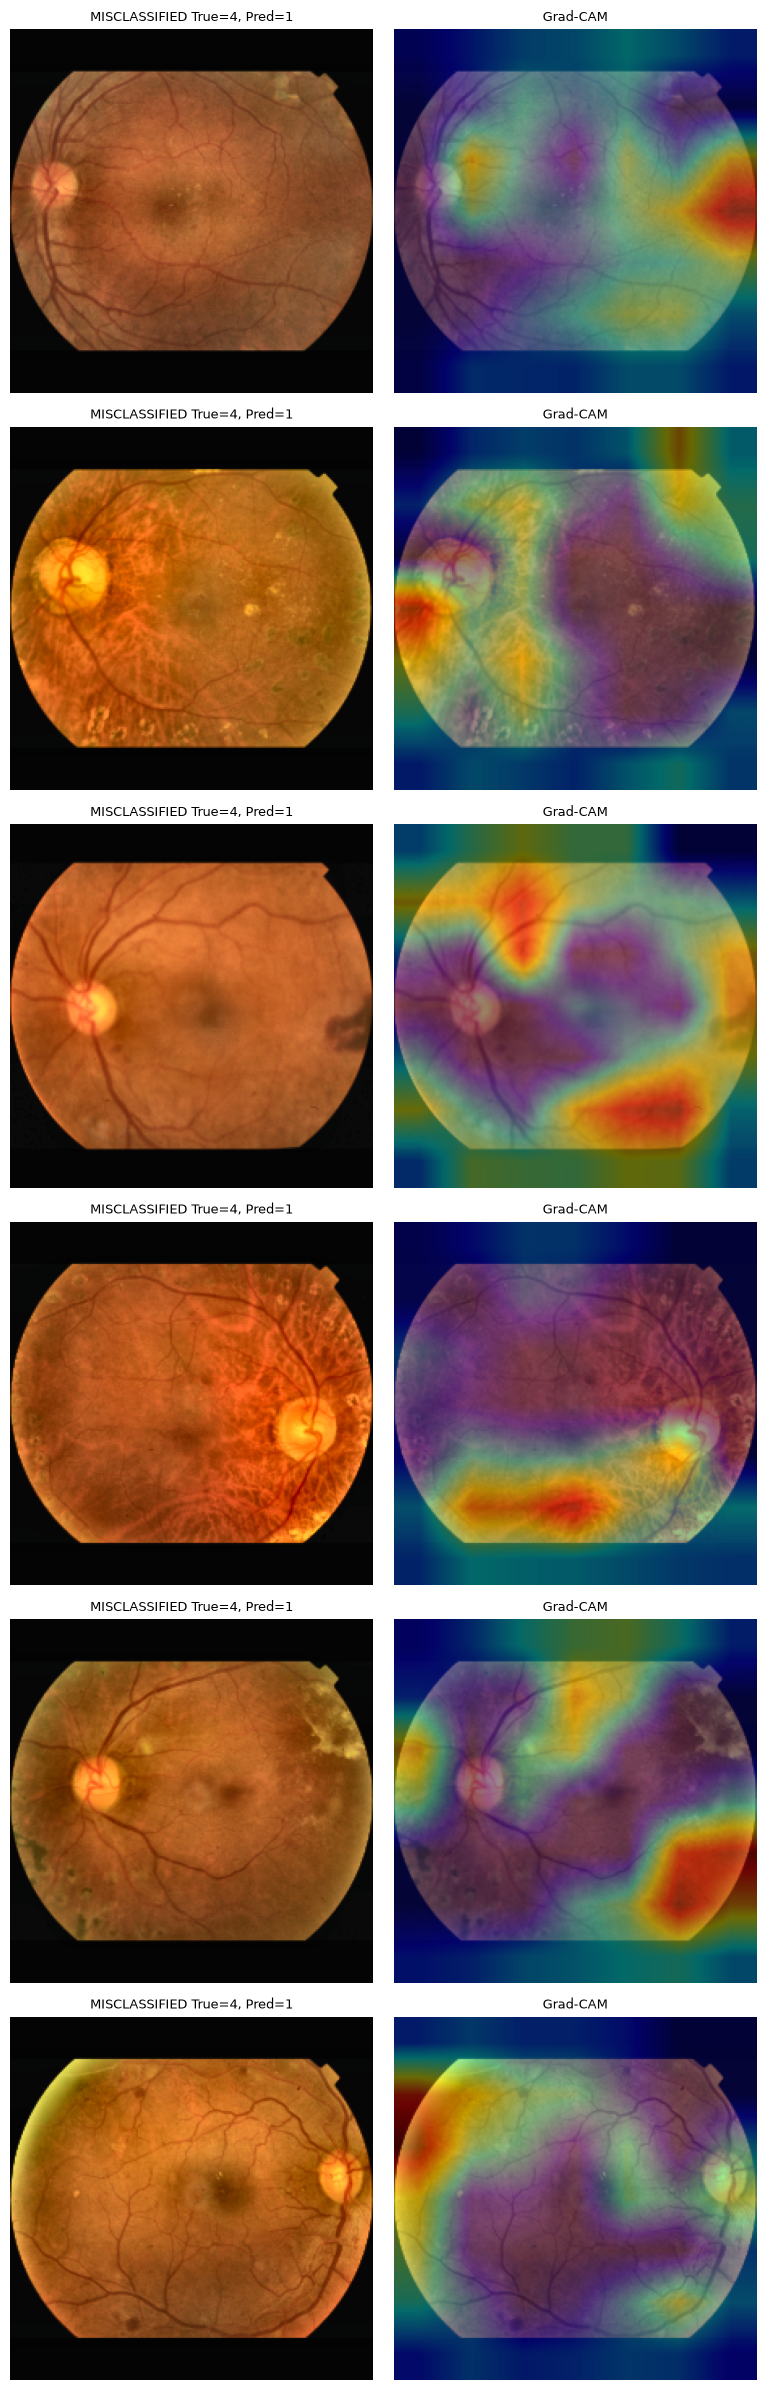

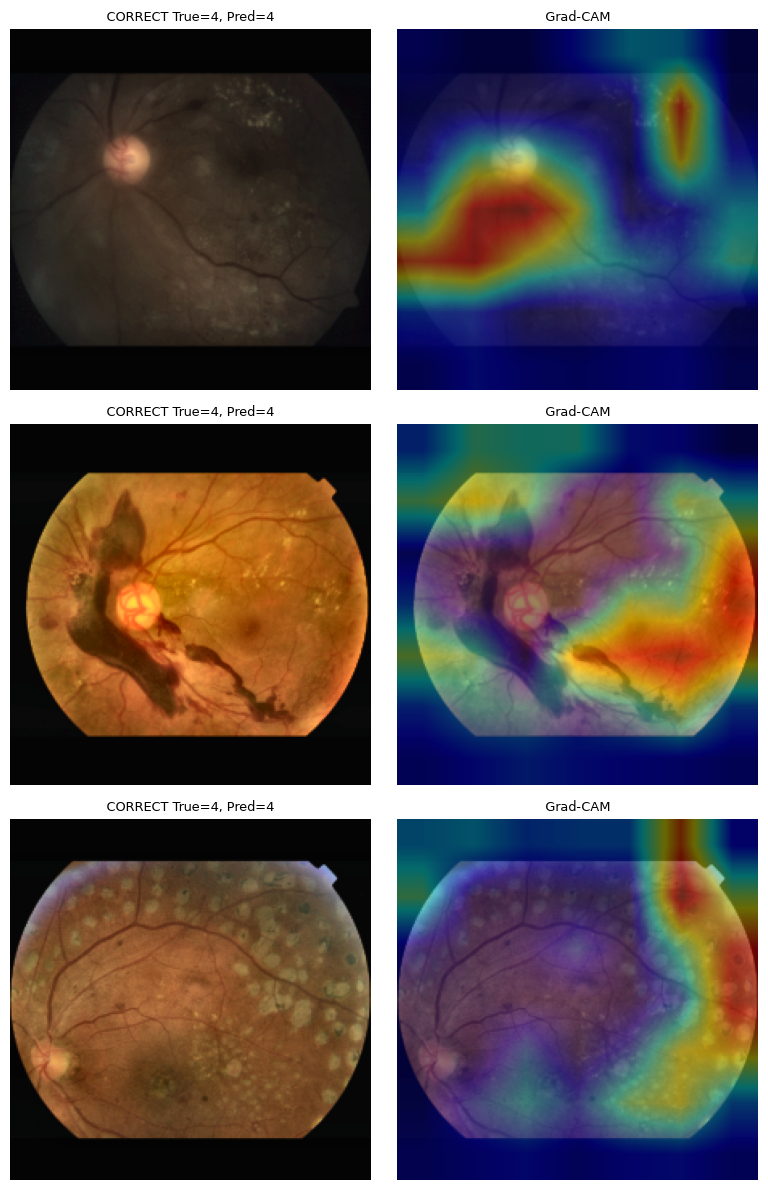

In [18]:

from preprocessing import full_pipeline_preprocess
import cv2

def visualize_gradcam_samples(indices, paths, true_labels, pred_labels, title_prefix=""):
    fig, axes = plt.subplots(len(indices), 2, figsize=(8, 4 * len(indices)))
    if len(indices) == 1:
        axes = axes.reshape(1, -1)

    for row, idx in enumerate(indices):
        img_path = paths[idx]
        img_bgr = cv2.imread(img_path)
        processed = full_pipeline_preprocess(img_bgr)  
        img_input = np.expand_dims(processed, axis=0)

        heatmap, pred_class = make_gradcam_heatmap(img_input, model, base_model)

        # de-normalize for display purposes only (EfficientNet preprocess_input is a no-op here,
        # so the raw processed array IS already display-range RGB — just clip/cast)
        display_img = np.clip(processed, 0, 255).astype(np.uint8)
        overlayed = overlay_heatmap(display_img, heatmap)

        axes[row, 0].imshow(display_img)
        axes[row, 0].set_title(f"{title_prefix} True={true_labels[idx]}, Pred={pred_labels[idx]}", fontsize=9)
        axes[row, 0].axis('off')

        axes[row, 1].imshow(overlayed)
        axes[row, 1].set_title("Grad-CAM", fontsize=9)
        axes[row, 1].axis('off')

    plt.tight_layout()
    plt.show()
    

# failure cases
visualize_gradcam_samples(misclassified_indices, test_paths, y_true, y_pred, title_prefix="MISCLASSIFIED")

# correctly classified Grade 4 cases
correct_grade4_indices = np.where((y_true == 4) & (y_pred == 4))[0][:3]
visualize_gradcam_samples(correct_grade4_indices, test_paths, y_true, y_pred, title_prefix="CORRECT")


Observation : 
the misclassified two figures shown here , 

the first one : Grad-CAM attention is tightly concentrated on the optic disc — a completely normal landmark, not disease tissue. The rest of the retina is essentially ignored. This shows that the model is anchoring on a generic, healthy-looking structure rather than searching the retina for lesions, and since this particular optic disc looks unremarkable, it predicted "no DR."

the second one : attention lands on the vessel-proliferation-like structures near the optic disc . Here the model is actually looking in a reasonable place, but still got the severity badly wrong. This looks more like a genuinely hard, subtle case than a shortcut failure.